# 02 EDA Visualization

This notebook is a guided tour of the data. We start by checking how the labels behave, then look at where the pollution is coming from, and finally inspect the weather patterns that may be helping or hurting the readings. Think of it as a first walk through the city before deciding where to build the model.

## Load Data and Parse Timestamps

First we bring in the raw CSV and make sure the timestamp column is usable. This is like putting labels on a stack of weather logs before sorting them into neat piles.

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/raw/air_quality_readings.csv")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

label_cols = [
    "label_respiratory_risk",
    "label_cardiovascular_risk",
    "label_vulnerable_alert",
    "label_outdoor_warning",
    "label_industrial_event",
]

group_cols = ["station_type", "station_id", "season", "hour", "temp_inversion"]

# Load the raw data and parse timestamps.
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["season"] = df["season"].astype(str).str.strip().str.title()
df["station_type"] = df["station_type"].astype(str).str.strip().str.title()

df.head()

,reading_id,timestamp,year,month,hour,day_of_week,is_weekend,is_rush_hour,season,station_id,station_type,elevation_m,near_highway,near_industry,temp_c,humidity_pct,wind_speed_ms,wind_dir_deg,pressure_hpa,precipitation_mm,visibility_km,temp_inversion,pm25,pm10,no2,o3,so2,co,benzene,aqi,label_respiratory_risk,label_cardiovascular_risk,label_vulnerable_alert,label_outdoor_warning,label_industrial_event
0,RDG0003315,2021-12-24 18:00:00,2021,12,18,4,0,1,Winter,STN_URBAN_01,Urban,100.4,1,0,11.9,60.4,0.5,NaN,1016.5,1.0,14.7,0,58.3,92.0,61.9,33.2,0.7,6.01,3.24,152,1,1,1,1,0
1,RDG0009080,2023-09-19 21:00:00,2023,9,21,1,0,0,Fall,STN_SUBURB_01,Suburban,61.9,0,0,18.4,45.4,12.4,246.1,1017.4,0.0,6.2,0,8.5,16.2,63.6,8.9,13.2,0.59,5.00,35,0,0,0,0,0
2,RDG0005620,2022-08-28 11:00:00,2022,8,11,6,1,0,Summer,STN_SUBURB_01,Suburban,27.1,0,0,26.7,52.9,2.9,239.5,1010.6,0.0,4.3,0,13.2,23.0,16.5,74.8,3.3,1.61,2.55,53,0,0,1,0,0
3,RDG0009213,2023-10-05 06:00:00,2023,10,6,3,0,0,Fall,STN_URBAN_02,Urban,96.1,0,0,18.2,43.4,1.9,345.0,1018.5,0.0,12.4,0,20.1,41.5,58.1,17.0,22.5,1.50,NaN,68,0,0,1,0,0
4,RDG0009206,2023-10-04 05:00:00,2023,10,5,2,0,0,Fall,STN_INDUSTRIAL_01,Industrial,11.8,1,1,9.4,43.0,17.5,24.7,1007.1,10.0,3.6,0,25.5,48.2,66.4,30.8,33.9,3.31,6.20,79,0,0,1,0,1


## Compute Target Frequency and Label Cardinality

Here we check how often each alert appears and how many alerts a single reading can trigger. If one reading is a sentence in the story, this section tells us whether it usually speaks in one short line or a whole paragraph of warnings.

Label prevalence:


,positive_rate
label_vulnerable_alert,0.733347
label_industrial_event,0.354507
label_outdoor_warning,0.312026
label_respiratory_risk,0.285102
label_cardiovascular_risk,0.180893


Label count summary:


,count,pct
0,1802,17.97
1,3248,32.39
2,1964,19.59
3,1140,11.37
4,1255,12.51
5,619,6.17


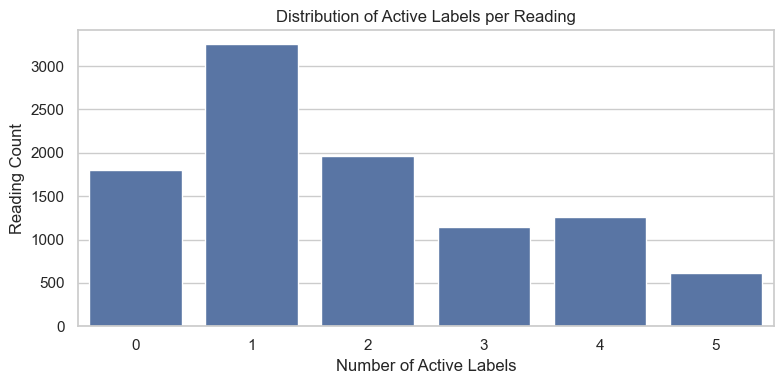

In [ ]:
label_rates = df[label_cols].mean().sort_values(ascending=False)
label_counts = df[label_cols].sum(axis=1)

summary = pd.DataFrame({
    "count": label_counts.value_counts().sort_index(),
    "pct": label_counts.value_counts(normalize=True).sort_index().mul(100).round(2),
})

print("Label prevalence:")
display(label_rates.to_frame("positive_rate"))

print("Label count summary:")
display(summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(x=label_counts, color="#4C72B0", ax=ax)
ax.set_title("Distribution of Active Labels per Reading")
ax.set_xlabel("Number of Active Labels")
ax.set_ylabel("Reading Count")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "label_count_distribution.png", dpi=300, bbox_inches="tight")

## Plot Label Co-occurrence Heatmap

Some alerts tend to travel together, almost like neighbors who always show up at the same event. This heatmap shows which labels like to appear in the same reading.

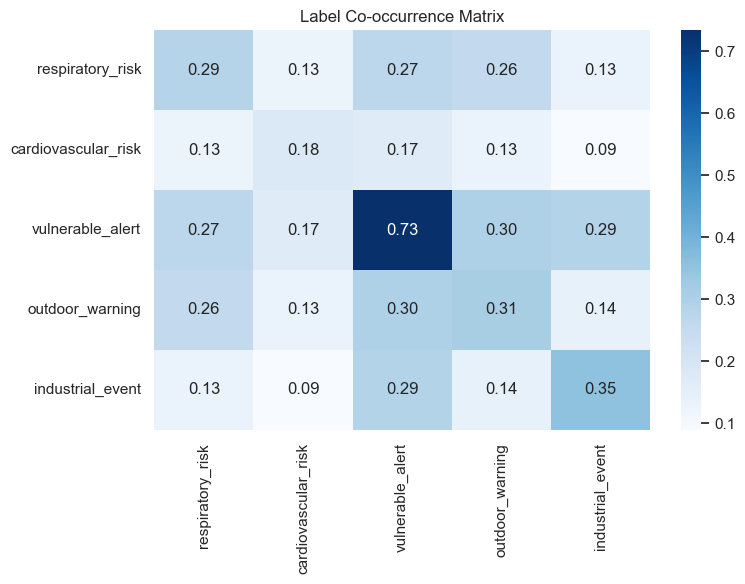

In [ ]:
co_occ = df[label_cols].T.dot(df[label_cols])
co_occ_norm = co_occ / len(df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    co_occ_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[c.replace("label_", "") for c in label_cols],
    yticklabels=[c.replace("label_", "") for c in label_cols],
)
plt.title("Label Co-occurrence Matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "label_cooccurrence.png", dpi=300, bbox_inches="tight")

## Plot Pollutant Distributions by Station Type

This is the city-vs-countryside view. We compare the main pollutants across station types to see whether industrial, urban, suburban, and rural stations really do tell different pollution stories.

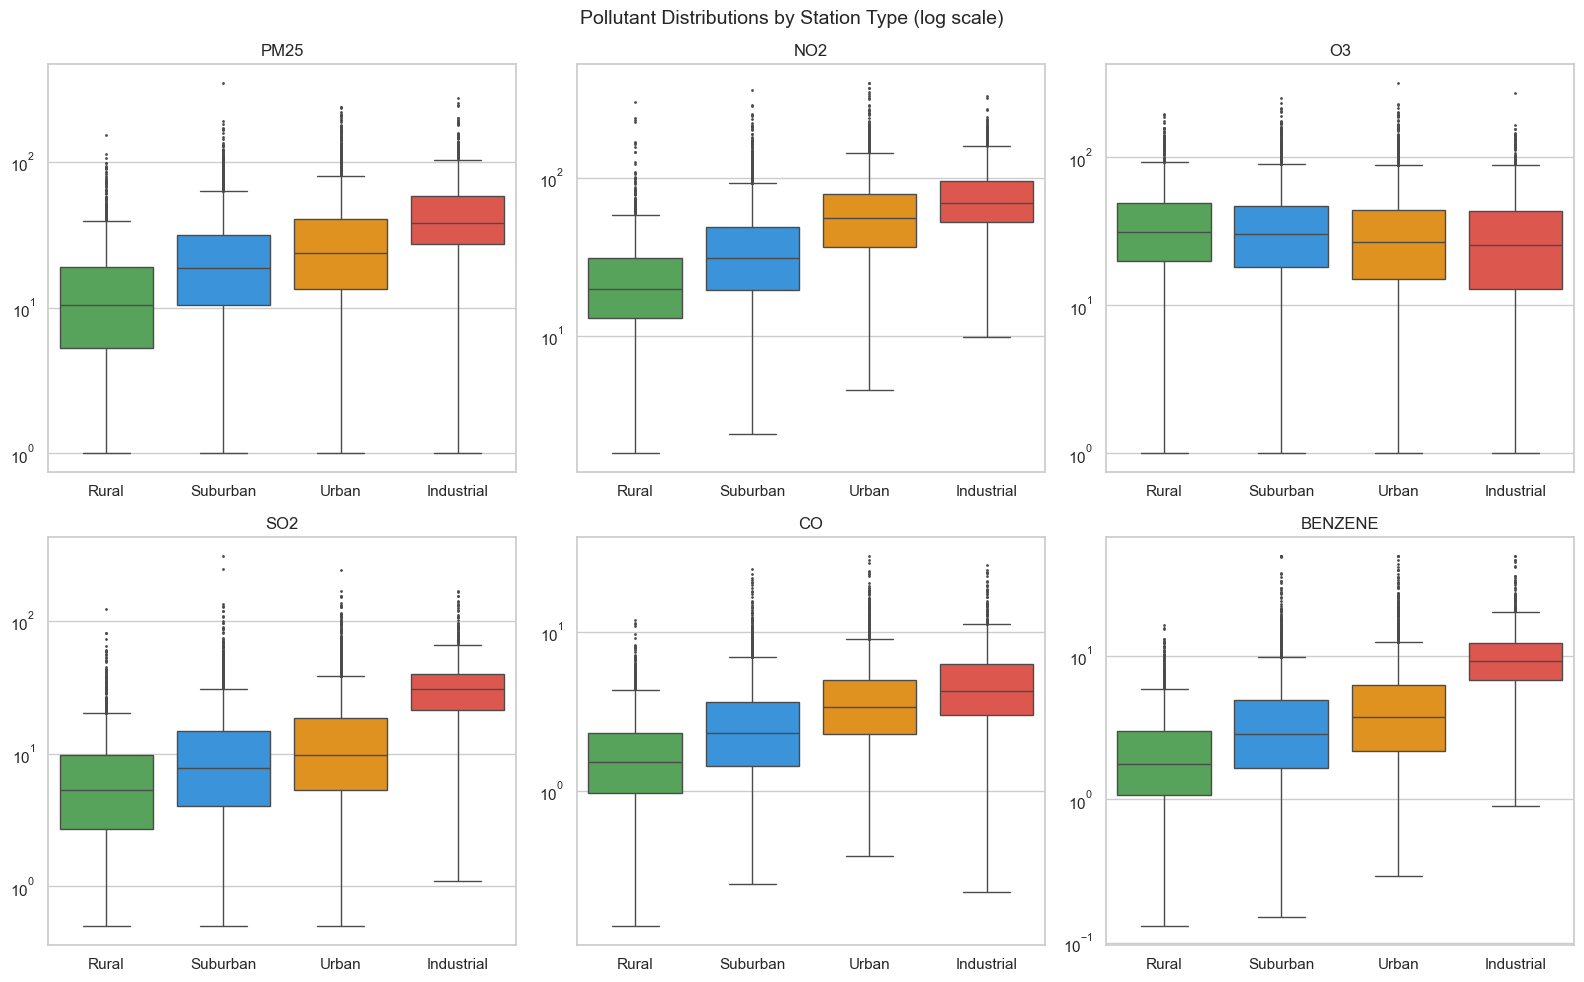

In [ ]:
pollutants = ["pm25", "no2", "o3", "so2", "co", "benzene"]
station_order = ["Rural", "Suburban", "Urban", "Industrial"]
palette = {
    "Rural": "#4CAF50",
    "Suburban": "#2196F3",
    "Urban": "#FF9800",
    "Industrial": "#F44336",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, pol in zip(axes.flat, pollutants):
    df_plot = df[["station_type", pol]].dropna()
    sns.boxplot(
        data=df_plot,
        x="station_type",
        y=pol,
        order=station_order,
        palette=palette,
        ax=ax,
        fliersize=1,
    )
    ax.set_title(pol.upper())
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Pollutant Distributions by Station Type (log scale)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pollutant_distributions.png", dpi=300, bbox_inches="tight")

## Plot Season × Hour PM2.5 Heatmap

Pollution is not static. It changes with the time of day and the time of year, so this heatmap helps us see when the air gets heavier, almost like watching the city breathe in and out.

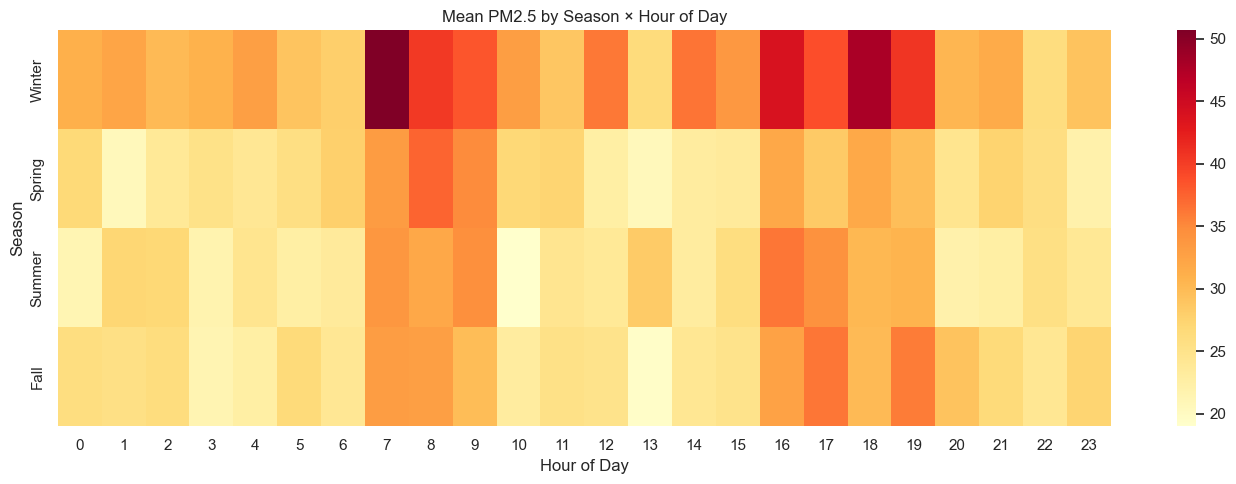

In [ ]:
season_order = ["Winter", "Spring", "Summer", "Fall"]
pivot = df.groupby(["season", "hour"])["pm25"].mean().unstack()
pivot = pivot.reindex(season_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="YlOrRd", annot=False, linewidths=0, xticklabels=range(24))
plt.title("Mean PM2.5 by Season × Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Season")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pm25_season_hour.png", dpi=300, bbox_inches="tight")

## Compare PM2.5 on Inversion vs Non-Inversion Days

Temperature inversions act a bit like a lid on a pot: they trap pollution close to the ground instead of letting it disperse. This plot shows how PM2.5 behaves when that lid is on versus when it is off.

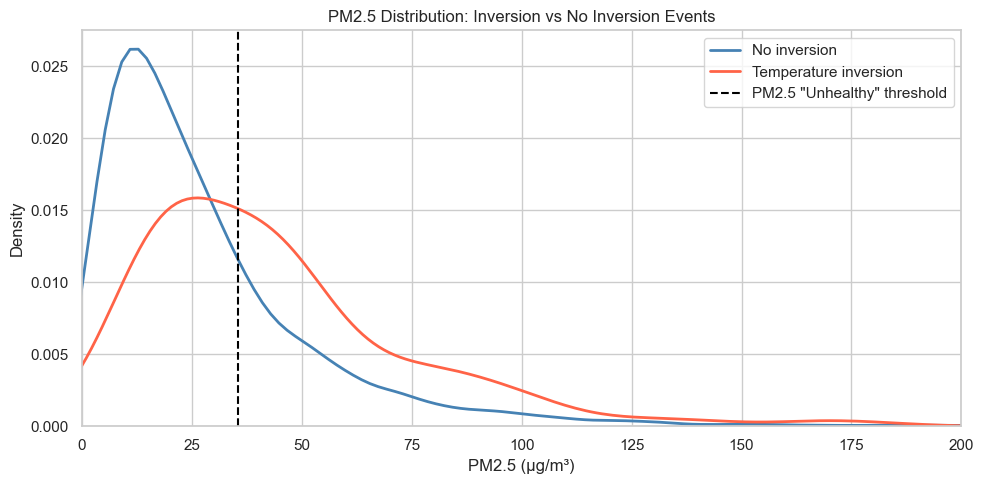

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(data=df[df["temp_inversion"] == 0], x="pm25", ax=ax, color="steelblue", label="No inversion", linewidth=2)
sns.kdeplot(data=df[df["temp_inversion"] == 1], x="pm25", ax=ax, color="tomato", label="Temperature inversion", linewidth=2)
ax.axvline(35.4, color="black", linestyle="--", label='PM2.5 "Unhealthy" threshold')
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_xlim(0, 200)
ax.set_title("PM2.5 Distribution: Inversion vs No Inversion Events")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "pm25_inversion_comparison.png", dpi=300, bbox_inches="tight")